# Machine Unlearning - App Usage Prediction

## Model Mimarisi
- **Input**: sin/cos cyclical encoding of hour (2 neuron)
- **Hidden 1**: 16 neuron + ReLU
- **Hidden 2**: 16 neuron + ReLU
- **Output**: 4 neuron + Softmax → [Instagram, YouTube, LinkedIn, WhatsApp]

Her kullanıcı için ayrı model **tüm veriyle** eğitilir (train/test split yok).
Amaç: Federated Learning öncesi her modelin bireysel pattern'leri tam öğrendiğini doğrulamak.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import math
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 1. Veri Yükleme ve Feature Engineering

Timestamp → **local saat (Europe/Istanbul)** → sin/cos cyclical encoding

In [2]:
APP_TO_IDX = {
    "com.instagram.android": 0,
    "com.google.android.youtube": 1,
    "com.linkedin.android": 2,
    "com.whatsapp": 3
}
IDX_TO_LABEL = {0: "Instagram", 1: "YouTube", 2: "LinkedIn", 3: "WhatsApp"}

LOCAL_TZ = "Europe/Istanbul"

def load_and_preprocess(csv_path):
    """CSV'den veri yukler, sin/cos encoding uygular, label encode eder."""
    df = pd.read_csv(csv_path)

    df["datetime"] = (
        pd.to_datetime(df["timestamp"], unit="ms", utc=True)
          .dt.tz_convert(LOCAL_TZ)
    )
    df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0

    df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24.0)

    df["label"] = df["packageName"].map(APP_TO_IDX)

    X = df[["sin_hour", "cos_hour"]].values.astype(np.float32)
    y = df["label"].values.astype(np.int64)

    return X, y, df

USER_FILES = {
    "user1": "app_usage_data_user1.csv",
    "user2": "app_usage_data_user2.csv",
    "user3": "app_usage_data_user3.csv"
}

datasets = {}
for user, path in USER_FILES.items():
    X, y, df = load_and_preprocess(path)
    datasets[user] = {"X": X, "y": y, "df": df}
    print(f"{user}: {len(X)} kayit (tumu train), label dagilimi: {dict(zip(*np.unique(y, return_counts=True)))}")

user1: 2289 kayit (tumu train), label dagilimi: {np.int64(0): np.int64(574), np.int64(1): np.int64(701), np.int64(2): np.int64(323), np.int64(3): np.int64(691)}
user2: 2128 kayit (tumu train), label dagilimi: {np.int64(0): np.int64(503), np.int64(1): np.int64(631), np.int64(2): np.int64(390), np.int64(3): np.int64(604)}
user3: 2171 kayit (tumu train), label dagilimi: {np.int64(0): np.int64(535), np.int64(1): np.int64(664), np.int64(2): np.int64(415), np.int64(3): np.int64(557)}


## 2. Model Mimarisi

`Input(2) → Hidden(16, ReLU) → Hidden(16, ReLU) → Output(4)`

In [3]:
class AppUsageModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)

dummy = AppUsageModel().to(device)
print("Model yapisi:")
print(dummy)
print(f"\nToplam parametre: {sum(p.numel() for p in dummy.parameters())}")

Model yapisi:
AppUsageModel(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)

Toplam parametre: 388


## 3. Eğitim (Full Data - No Split)

Tüm veri eğitim için kullanılır. Train/test split yok.

In [4]:
def train_model(X, y, epochs=100, batch_size=32, lr=0.01, verbose=True):
    """Tum veriyle model egitir. Train/test split yok."""
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = AppUsageModel().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    train_losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_X.size(0)

        avg_loss = epoch_loss / len(dataset)
        train_losses.append(avg_loss)

        if verbose and (epoch + 1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                preds = model(X_t).argmax(dim=1)
                acc = (preds == y_t).float().mean().item()
            print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {acc:.4f}")

    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        final_acc = (preds == y_t).float().mean().item()

    return model, train_losses, final_acc

## 4. Her Kullanıcı İçin Model Eğitimi

In [5]:
trained_models = {}

for user in ["user1", "user2", "user3"]:
    print(f"\n{'='*50}")
    print(f"  {user.upper()} MODEL EGITIMI ({len(datasets[user]['X'])} kayit)")
    print(f"{'='*50}")

    X, y = datasets[user]["X"], datasets[user]["y"]
    model, losses, acc = train_model(X, y)

    trained_models[user] = {"model": model, "losses": losses, "accuracy": acc}

    print(f"\n  Final Train Accuracy: {acc:.4f} ({acc*100:.1f}%)")


  USER1 MODEL EGITIMI (2289 kayit)


  Epoch  20/100 | Loss: 1.1861 | Train Acc: 0.4089


  Epoch  40/100 | Loss: 1.1756 | Train Acc: 0.4225


  Epoch  60/100 | Loss: 1.1721 | Train Acc: 0.4168


  Epoch  80/100 | Loss: 1.1695 | Train Acc: 0.4312


...

  Epoch  20/100 | Loss: 0.9240 | Train Acc: 0.6034


  Epoch  40/100 | Loss: 0.9058 | Train Acc: 0.5933


  Epoch  60/100 | Loss: 0.9059 | Train Acc: 0.5914


  Epoch  80/100 | Loss: 0.9081 | Train Acc: 0.5960


  Epoch 100/100 | Loss: 0.9004 | Train Acc: 0.6053

  Final Train Accuracy: 0.6053 (60.5%)


## 5. Ağırlıkları JSON Olarak Kaydetme

In [6]:
def save_weights_json(model, filepath):
    """Model agirliklarini JSON formatinda kaydeder."""
    state_dict = model.state_dict()
    serializable = {}
    for key, tensor in state_dict.items():
        serializable[key] = tensor.cpu().tolist()

    with open(filepath, "w") as f:
        json.dump(serializable, f, indent=2)
    print(f"  Kaydedildi: {filepath}")

def load_weights_json(model, filepath):
    """JSON'dan agirliklari yukler."""
    with open(filepath, "r") as f:
        data = json.load(f)

    state_dict = {}
    for key, values in data.items():
        state_dict[key] = torch.tensor(values)

    model.load_state_dict(state_dict)
    return model

os.makedirs("weights", exist_ok=True)

for user, data in trained_models.items():
    save_weights_json(data["model"], f"weights/{user}_weights.json")

print("\nKaydedilen weight dosyalari:")
for f in os.listdir("weights"):
    size_kb = os.path.getsize(f"weights/{f}") / 1024
    print(f"  {f}: {size_kb:.1f} KB")

  Kaydedildi: weights/user1_weights.json
  Kaydedildi: weights/user2_weights.json
  Kaydedildi: weights/user3_weights.json

Kaydedilen weight dosyalari:
  user1_weights.json: 11.3 KB
  user2_weights.json: 11.2 KB
  user3_weights.json: 11.2 KB


## 6. Saat Bazlı Tahmin Doğrulama (Local Saat - Europe/Istanbul)

In [7]:
def predict_for_hours(model, hours):
    """Verilen saat listesi icin tahmin yapar (local saat)."""
    results = []
    for h in hours:
        sin_h = math.sin(2 * math.pi * h / 24.0)
        cos_h = math.cos(2 * math.pi * h / 24.0)
        x = torch.FloatTensor([[sin_h, cos_h]]).to(device)
        probs = model.predict_proba(x)[0].cpu().numpy()
        pred_idx = probs.argmax()
        results.append({
            "hour": h,
            "prediction": IDX_TO_LABEL[pred_idx],
            "confidence": probs[pred_idx],
            "probs": probs
        })
    return results

expected_patterns = {
    "user1": "08-10: Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram",
    "user2": "08-10: YouTube | 12-14: Instagram | 14-18: LinkedIn+WhatsApp",
    "user3": "08-10: WhatsApp | 18-22: YouTube | 22-02: Instagram"
}

for user in ["user1", "user2", "user3"]:
    print(f"\n{'='*60}")
    print(f"  {user.upper()} - SAAT BAZLI TAHMINLER (LOCAL)")
    print(f"  Beklenen: {expected_patterns[user]}")
    print(f"  Train Acc: {trained_models[user]['accuracy']*100:.1f}%")
    print(f"{'='*60}")

    model = trained_models[user]["model"]
    results = predict_for_hours(model, range(24))

    print(f" {'saat':>5}  {'tahmin':>9} {'guven':>5}  {'Instagram':>9} {'YouTube':>7} {'LinkedIn':>8} {'WhatsApp':>8}")
    for r in results:
        p = r["probs"]
        print(f" {r['hour']:02d}:00  {r['prediction']:>9} {r['confidence']*100:4.1f}%  "
              f"{p[0]*100:8.1f}% {p[1]*100:7.1f}% {p[2]*100:8.1f}% {p[3]*100:8.1f}%")


  USER1 - SAAT BAZLI TAHMINLER (LOCAL)
  Beklenen: 08-10: Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram
  Train Acc: 41.8%
  saat     tahmin guven  Instagram YouTube LinkedIn WhatsApp
 00:00   WhatsApp 40.9%      16.9%    36.6%      5.6%     40.9%
 01:00   WhatsApp 42.7%      15.8%    35.6%      5.9%     42.7%
 02:00   WhatsApp 45.0%      13.6%    35.1%      6.2%     45.0%
 03:00    YouTube 44.7%       9.0%    44.7%      4.1%     42.2%
 04:00    YouTube 45.8%      11.6%    45.8%      3.6%     39.0%
 05:00    YouTube 44.4%      12.6%    44.4%      4.2%     38.8%
 06:00    YouTube 44.4%      12.4%    44.4%      4.1%     39.2%
 07:00    YouTube 43.6%      13.2%    43.6%      3.9%     39.3%
 08:00  Instagram 59.5%      59.5%    19.4%      3.0%     18.1%
 09:00  Instagram 99.1%      99.1%     0.4%      0.1%      0.3%
 10:00    YouTube 43.4%       9.5%    43.4%     15.7%     31.4%
 11:00    YouTube 40.0%      12.6%    40.0%     15.2%     32.2%
 12:00    YouTube 35.3%      

## 7. Training Loss Grafikleri

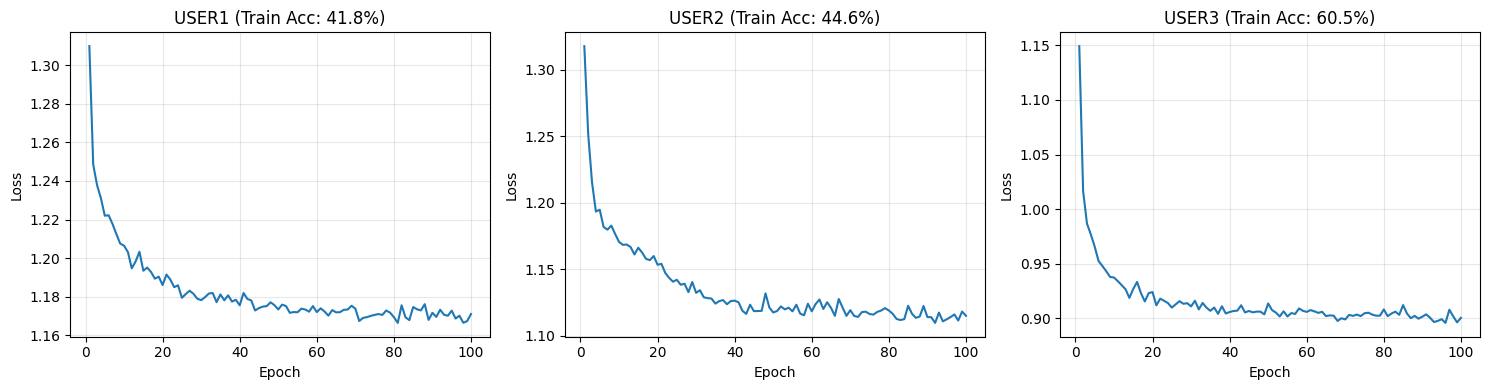

Grafik kaydedildi: training_loss.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, user in enumerate(["user1", "user2", "user3"]):
    ax = axes[idx]
    losses = trained_models[user]["losses"]
    acc = trained_models[user]["accuracy"]
    ax.plot(range(1, len(losses)+1), losses, linewidth=1.5)
    ax.set_title(f"{user.upper()} (Train Acc: {acc*100:.1f}%)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Grafik kaydedildi: training_loss.png")